In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load df from CSV
df = pd.read_csv("../assets/outputs/bbch_df.csv", parse_dates=['date'])
print(df.shape)
df.head()

(4652, 28)


,date,station,depth,op,mean_sst,mean_airt,SSM,SST,year,doy,...,VH,VV,angle,lc,BASE_TEMP,cum_GDD_air,cum_GDD_soil,cum_GDD,BBCH,cum_SSM
0,2015-04-25,MB1,0 to 5 cm,0,10.185,7.835,0.130000,14.977778,2015,115,...,-20.0,-13.0,40.0,146,5,2.835,5.185,4.0100,0.0,0.130000
1,2015-04-25,MB10,0 to 5 cm,0,7.500,7.840,0.432222,12.633333,2015,115,...,-27.0,-20.0,43.0,146,5,5.675,7.685,6.6800,0.0,0.562222
2,2015-04-25,MB11,0 to 5 cm,0,8.635,8.380,0.272222,12.577778,2015,115,...,-22.0,-14.0,42.0,158,10,5.675,7.685,6.6800,0.0,0.834444
3,2015-04-25,MB12,0 to 5 cm,0,5.350,8.015,0.310000,14.266667,2015,115,...,-22.0,-12.0,42.0,146,5,8.690,8.035,8.3625,0.0,1.144444
4,2015-04-25,MB2,0 to 5 cm,0,13.265,8.305,0.340000,15.955556,2015,115,...,-19.0,-9.0,40.0,146,5,11.995,16.300,14.1475,0.0,1.484444


In [3]:
from inversion import Inverse

# Set the bacscattering models
RT_models = {
    'RT_s': 'PRISM1', # options: 'AIEM', 'PRISM1'
    'RT_c': 'Diff' # options: 'Diffuse', 'Specular'
}

inv = Inverse(workspace_dir='../assets', fGHz=5.405, models=RT_models, acftype='exp')
inv_df = inv.run(df)

/home/debian/usask_work/CSA-N2O-GEE/.venv/lib/python3.11/site-packages/ssrt/core.py:58: RuntimeWarning: invalid value encountered in divide
  self.eps_ratio = eps3 / eps2
/home/debian/usask_work/CSA-N2O-GEE/.venv/lib/python3.11/site-packages/ssrt/utils/fresnel.py:16: RuntimeWarning: invalid value encountered in divide
  gamma0 = np.abs((1 - sqrt_eps) / (1 + sqrt_eps)) ** 2
/home/debian/usask_work/CSA-N2O-GEE/.venv/lib/python3.11/site-packages/ssrt/utils/fresnel.py:64: RuntimeWarning: invalid value encountered in divide
  sin_theta_ratio = (n1 * sin_theta) / n2
/home/debian/usask_work/CSA-N2O-GEE/.venv/lib/python3.11/site-packages/ssrt/utils/fresnel.py:67: RuntimeWarning: invalid value encountered in divide
  rho_v = -(n2 * np.cos(theta_rad) - n1 * costh2) / (n2 * np.cos(theta_rad) + n1 * costh2)
/home/debian/usask_work/CSA-N2O-GEE/.venv/lib/python3.11/site-packages/ssrt/utils/fresnel.py:68: RuntimeWarning: invalid value encountered in divide
  rho_h =  (n1 * np.cos(theta_rad) - n2 * co

In [4]:
print(inv_df.shape)
inv_df.head()

(4533, 39)


,date,station,depth,op,mean_sst,mean_airt,SSM,SST,year,doy,...,c,w,vvv,vvs,s,l,rvi,height,k,b
0,2015-04-25,MB1,0 to 5 cm,0,10.185,7.835,0.130000,14.977778,2015,115,...,0.222963,0.038395,-15.194094,-17.016249,0.002823,0.075,0.665350,0.542280,80.0,1.0
1,2015-04-25,MB10,0 to 5 cm,0,7.500,7.840,0.432222,12.633333,2015,115,...,0.299597,0.016298,-22.695383,-23.349850,0.000855,0.075,0.665350,0.542280,80.0,1.0
2,2015-04-25,MB11,0 to 5 cm,0,8.635,8.380,0.272222,12.577778,2015,115,...,0.387900,0.000163,-17.819667,-16.328337,0.002806,0.075,0.547228,0.228891,40.0,1.0
3,2015-04-25,MB12,0 to 5 cm,0,5.350,8.015,0.310000,14.266667,2015,115,...,0.295008,0.000308,-15.625036,-14.471887,0.003311,0.075,0.363636,0.300909,80.0,1.0
4,2015-04-25,MB2,0 to 5 cm,0,13.265,8.305,0.340000,15.955556,2015,115,...,0.235136,0.000298,-12.331738,-11.711022,0.004551,0.075,0.363636,0.300909,80.0,1.0


In [5]:
inv_df.columns

Index(['date', 'station', 'depth', 'op', 'mean_sst', 'mean_airt', 'SSM', 'SST',
       'year', 'doy', 'Station', 'Depth (cm)', 'bulk', 'Sand', 'Silt', 'Clay',
       'Classification', 'index', 'VH', 'VV', 'angle', 'lc', 'BASE_TEMP',
       'cum_GDD_air', 'cum_GDD_soil', 'cum_GDD', 'BBCH', 'cum_SSM', 'd', 'c',
       'w', 'vvv', 'vvs', 's', 'l', 'rvi', 'height', 'k', 'b'],
      dtype='object')

In [6]:
inv_df.to_csv("../assets/outputs/inv_df.csv", index=False)

In [16]:
inv_df['k'] = inv_df.k.astype(float)
inv_df['b'] = inv_df.b.astype(float)

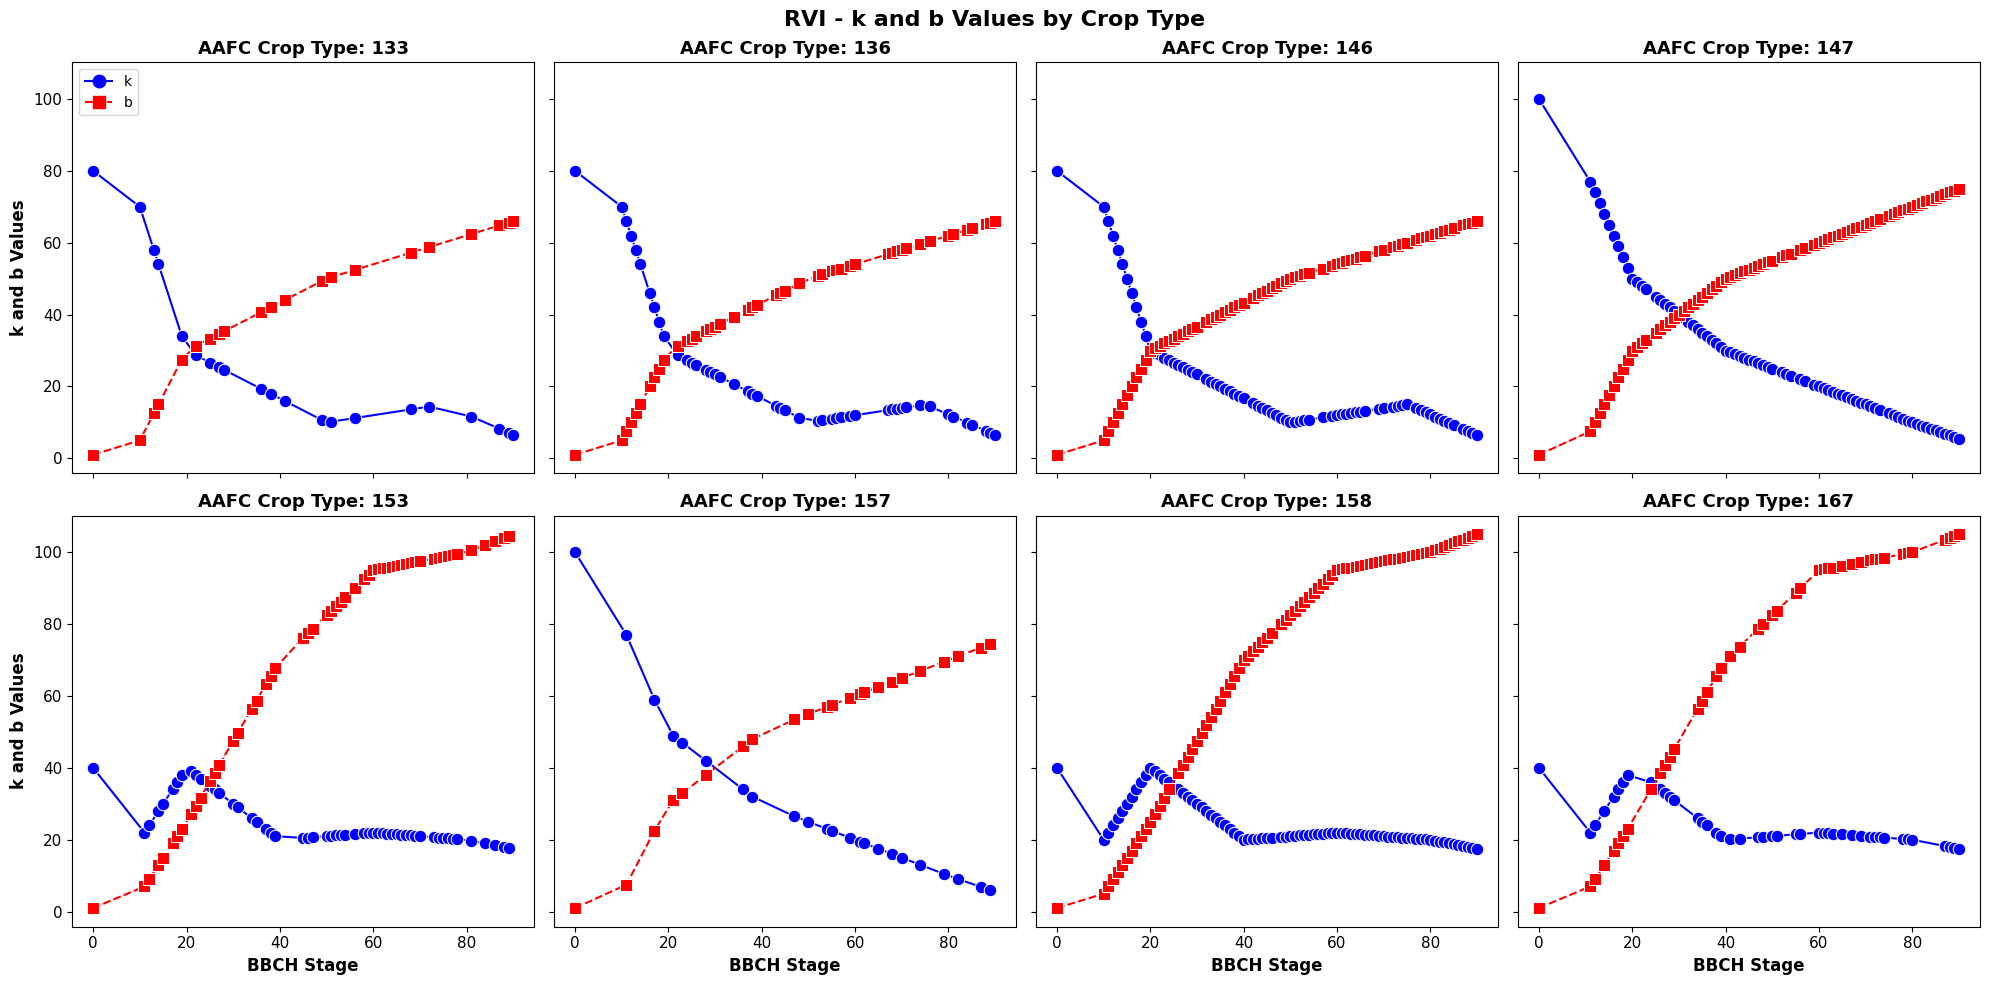

In [70]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('RVI - k and b Values by Crop Type', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = inv_df['lc'].unique() 
crop_types = sorted(crop_types)[:8]

# Plot both k and b values for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4
    col = i % 4

    crop_data = inv_df[inv_df['lc'] == crop]
    
    # Plot k values in blue
    sns.lineplot(x='BBCH', y='k', data=crop_data, linestyle='-', marker='o', 
                 markersize=9, color='blue', ax=axes[row, col])
    
    # Plot b values in red
    sns.lineplot(x='BBCH', y='b', data=crop_data, linestyle='--', marker='s', 
                 markersize=9, color='red', ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('BBCH Stage', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('k and b Values', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)

    # --- Add a legend just for the first subplot ---
    if i == 0:
        # Create custom legend handles to display in the first subplot
        k_line = mlines.Line2D([], [], color='blue', marker='o', linestyle='-', markersize=9, label='k')
        b_line = mlines.Line2D([], [], color='red', marker='s', linestyle='--', markersize=9, label='b')
        
        # Add the legend to the first subplot using the custom handles
        axes[row, col].legend(handles=[k_line, b_line], loc='upper left', fontsize=10)
        
plt.tight_layout()
plt.show()

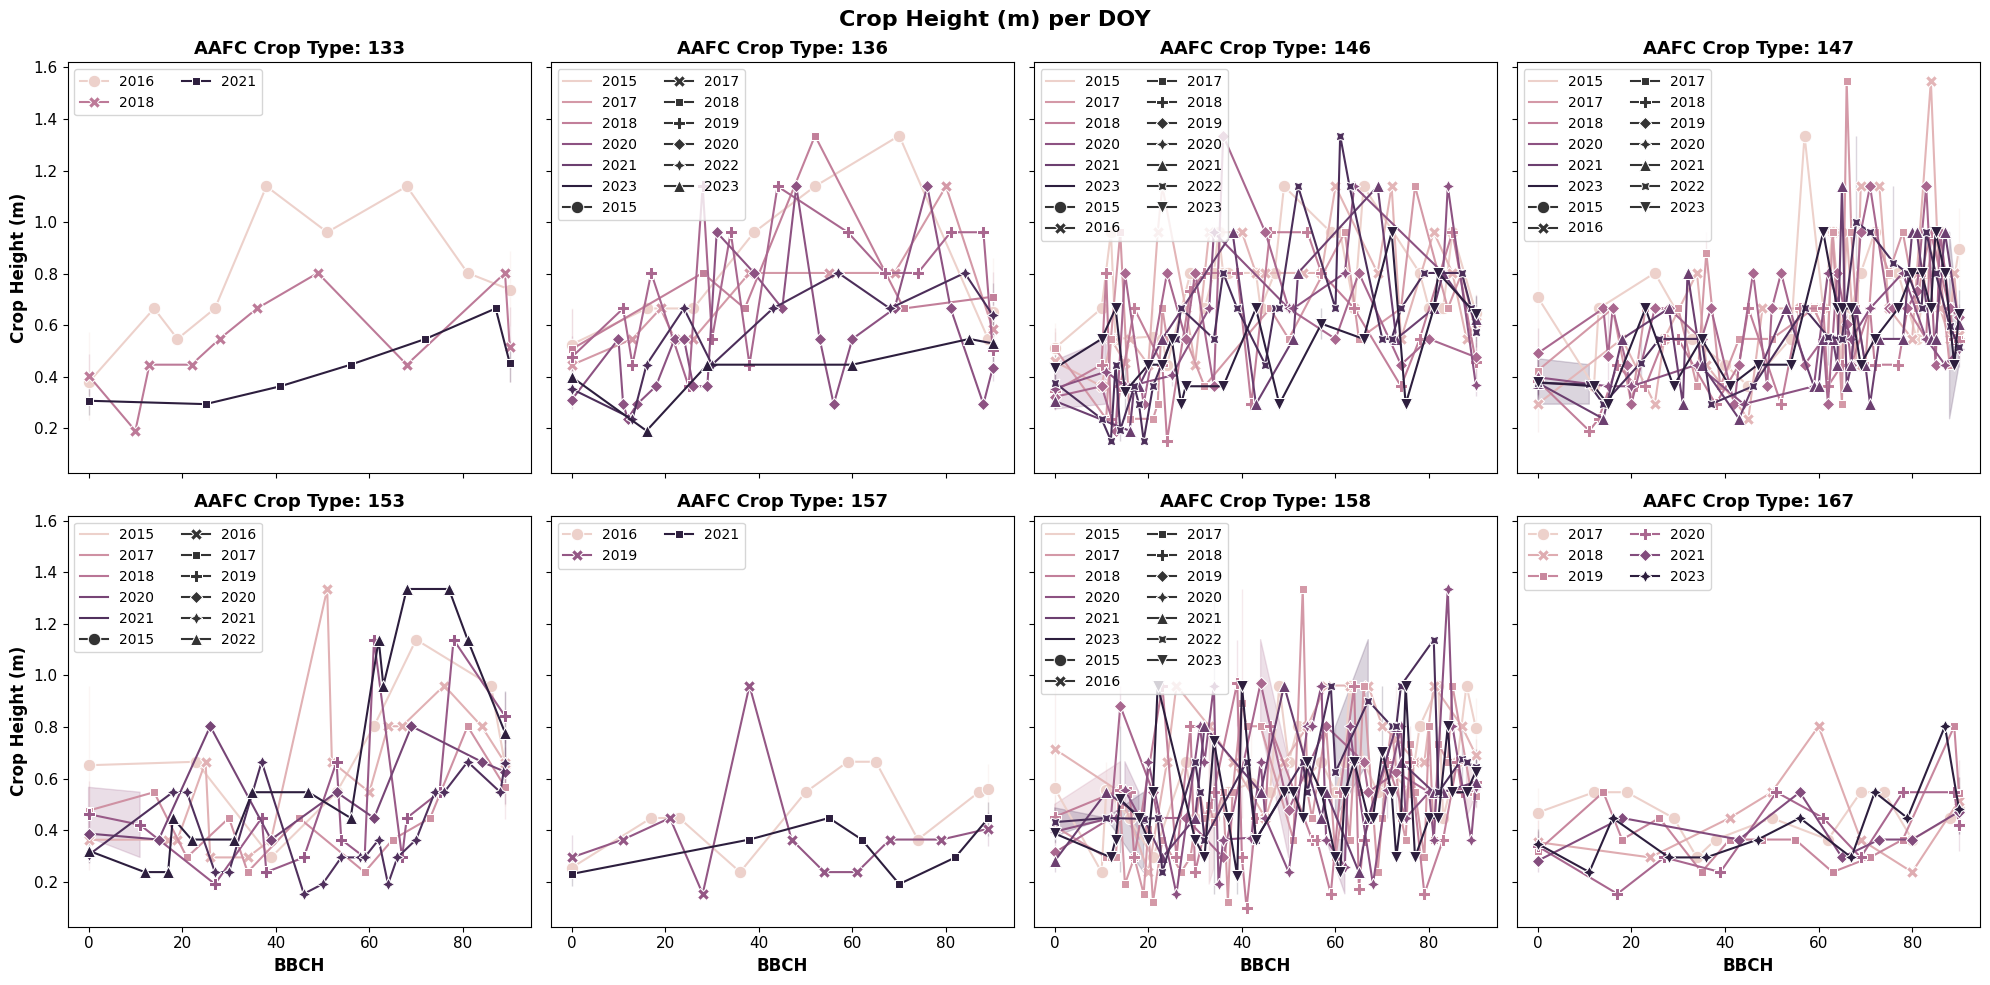

In [119]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('Crop Height (m) per DOY', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = inv_df['lc'].unique()  # Replace 'lc' with your crop type column name
crop_types = sorted(crop_types)[:8]  # Take all 8 crop types

# Plot crop height for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4  # Determine row (0 or 1)
    col = i % 4   # Determine column (0, 1, 2, or 3)
    
    crop_data = inv_df[inv_df['lc'] == crop]  # Replace 'lc' with your crop type column
    
    # Plot crop height vs DOY with year as hue and crop type as style
    sns.lineplot(x='BBCH', y='rvi', data=crop_data, 
                 hue='year', 
                 style='year', 
                 markers=True, dashes=False, markersize=9, ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('BBCH', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Crop Height (m)', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)
    
    # Adjust legend for each subplot
    legend = axes[row, col].get_legend()
    if legend:
        axes[row, col].legend(ncol=2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

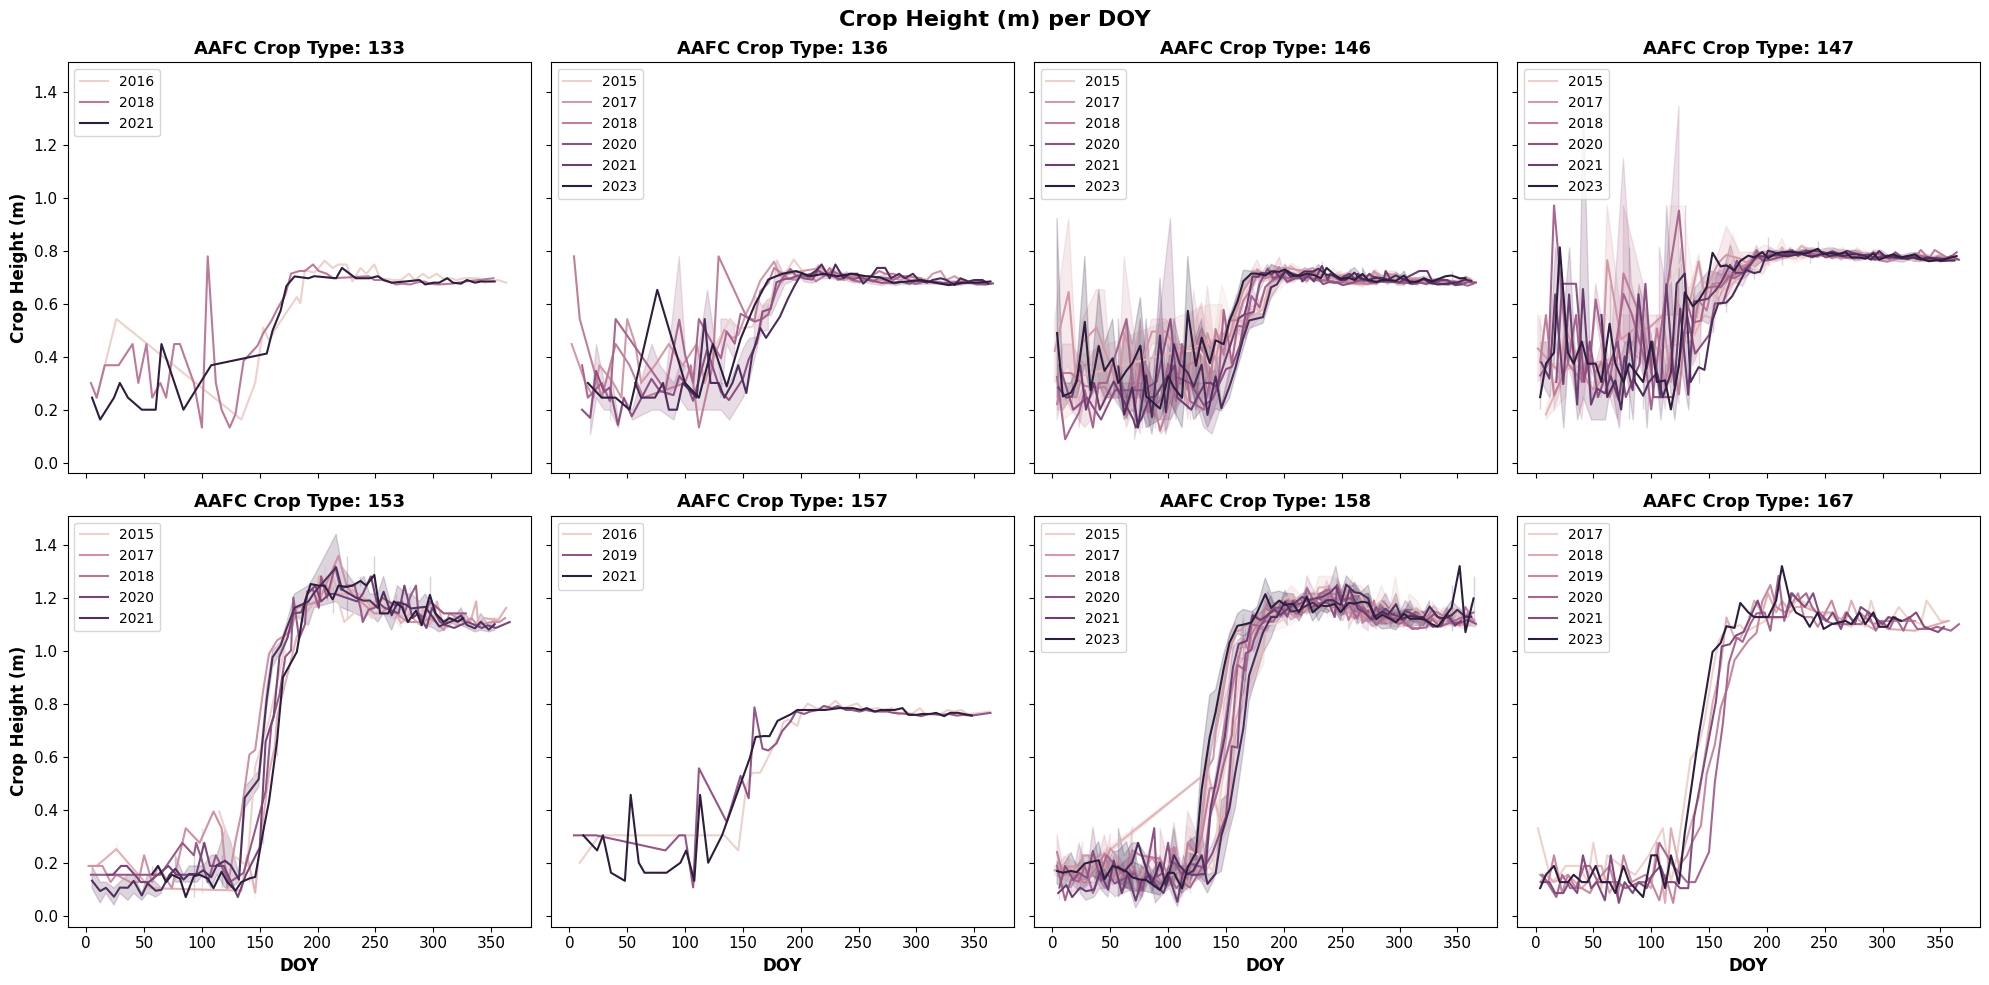

In [87]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('Crop Height (m) per DOY', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = inv_df['lc'].unique()  # Replace 'lc' with your crop type column name
crop_types = sorted(crop_types)[:8]  # Take all 8 crop types

# Plot crop height for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4  # Determine row (0 or 1)
    col = i % 4   # Determine column (0, 1, 2, or 3)
    
    crop_data = inv_df[inv_df['lc'] == crop]  # Replace 'lc' with your crop type column
    
    # Plot crop height vs DOY with year as hue and crop type as style
    sns.lineplot(x='doy', y='height', data=crop_data, hue='year', 
                #  style='BBCH', 
                markers=True, dashes=False, markersize=9, ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('DOY', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Crop Height (m)', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)
    
    # Adjust legend for each subplot
    legend = axes[row, col].get_legend()
    if legend:
        axes[row, col].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

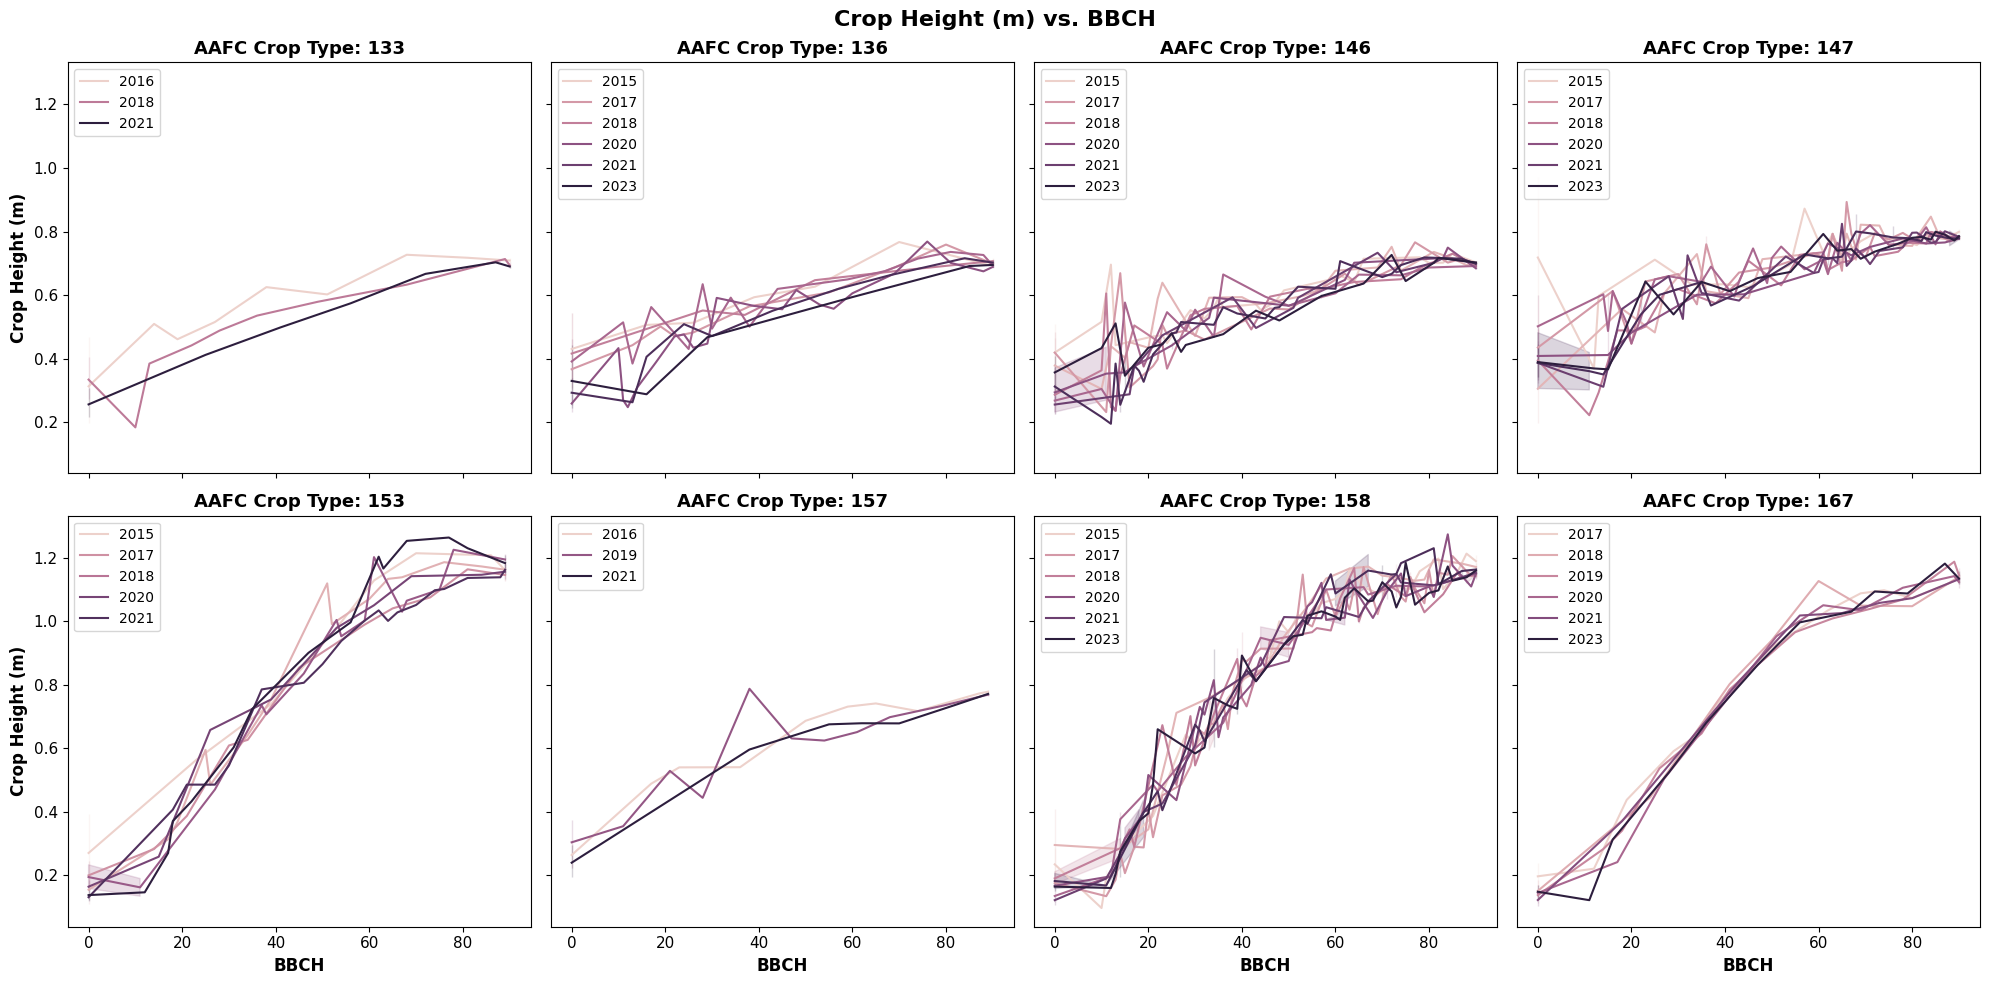

In [103]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('Crop Height (m) vs. BBCH', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = inv_df['lc'].unique()  # Replace 'lc' with your crop type column name
crop_types = sorted(crop_types)[:8]  # Take all 8 crop types

# Plot crop height for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4  # Determine row (0 or 1)
    col = i % 4   # Determine column (0, 1, 2, or 3)
    
    crop_data = inv_df[inv_df['lc'] == crop]  # Replace 'lc' with your crop type column
    
    # Plot crop height vs DOY with year as hue and crop type as style
    sns.lineplot(x='BBCH', y='height', data=crop_data, 
                 hue='year', 
                #  style='year', 
                markers=True, dashes=False, markersize=9, ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('BBCH', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Crop Height (m)', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)
    
    # Adjust legend for each subplot
    legend = axes[row, col].get_legend()
    if legend:
        axes[row, col].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

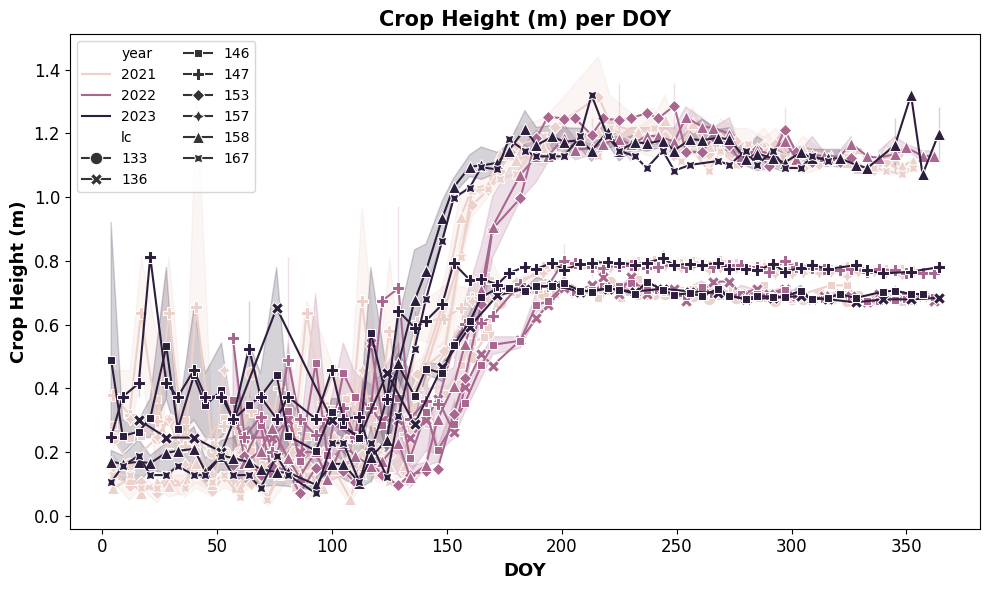

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='doy', y='height', data=inv_df[inv_df.year >= 2021], hue='year', style='lc', markers=True, dashes=False, markersize=9)
plt.xlabel('DOY', fontsize=13, fontweight='bold')
plt.ylabel('Crop Height (m)', fontsize=13, fontweight='bold')
plt.title('Crop Height (m) per DOY', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=2, loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'gp_merged' DataFrame is already created as in the provided code.

plt.figure(figsize=(10, 6))
sns.histplot(inv_df, x='SSM', kde=True, hue='lc')
plt.title('Histogram of SSM')
plt.xlabel('SSM')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Assuming 'gp_merged' DataFrame is already created as in the provided code.

parameters = ['VV', 'VH', 'vvs', 'vvv', 'SSM', 'SST', 'c', 's', 'l', 'd', 'w']
num_parameters = len(parameters)

fig, axes = plt.subplots(num_parameters, 1, figsize=(10, 3 * num_parameters), sharex=True)

for i, param in enumerate(parameters):
    sns.lineplot(ax=axes[i], x='doy', y=param, data=inv_df, hue='year', style='lc', legend=False)
    axes[i].set_title(param)
    # Add legend only to the first subplot
    if i == 0:
        axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()